# BÀI THI CUỐI KỲ: NGHIÊN CỨU KHOA HỌC 
## Dự đoán GDP Growth của quốc gia theo thời gian


**Họ và tên:** NGÔ PHƯƠNG THẢO

**MSSV:** [CH331217]

**Mục tiêu kỳ vọng**

- Xác định các yếu tố kinh tế quan trọng ảnh hưởng đến GDP Growth
- Phân tích xu hướng kinh tế toàn cầu qua thời gian
- Xây dựng mô hình dự báo GDP Growth bằng Machine Learning
- Đánh giá độ chính xác mô hình
- Rút ra insight kinh tế phục vụ chiến lược

**Nội dung phân tích:**

- Thu thập dữ liệu từ World Bank: GDP Growth, Population Growth, Inflation
- Chuẩn hóa cấu trúc dữ liệu


### I. DATA COLLECTION

In [287]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


In [288]:

def process_worldbank_file(file_path, value_name):
    df = pd.read_csv(file_path, skiprows=4)

    df = df.melt(
        id_vars=['Country Name', 'Country Code'],
        var_name='Year',
        value_name=value_name
    )

    df = df[df['Year'].astype(str).str.isnumeric()]
    df['Year'] = df['Year'].astype(int)

    return df


gdp = process_worldbank_file("gdp_growth.csv", "GDP_Growth")
population = process_worldbank_file("population_growth.csv", "Population_Growth")
inflation = process_worldbank_file("inflation.csv", "Inflation")


df = gdp.merge(
    population,
    on=['Country Name', 'Country Code', 'Year']
)

df = df.merge(
    inflation,
    on=['Country Name', 'Country Code', 'Year']
)

print("Data collected successfully!")
print(df.head())


Data collected successfully!
                  Country Name Country Code  Year GDP_Growth  \
0                        Aruba          ABW  1960        NaN   
1  Africa Eastern and Southern          AFE  1960        NaN   
2                  Afghanistan          AFG  1960        NaN   
3   Africa Western and Central          AFW  1960        NaN   
4                       Angola          AGO  1960        NaN   

  Population_Growth Inflation  
0               NaN       NaN  
1               NaN       NaN  
2               NaN       NaN  
3               NaN       NaN  
4               NaN       NaN  


### II. DATA CLEANING

In [289]:


# Remove missing values
df.dropna(inplace=True)

# Keep years >= 2000
df = df[df['Year'] >= 2000]

# Remove aggregated regions
df = df[df['Country Code'].str.len() == 3]

# Reset index
df.reset_index(drop=True, inplace=True)

print("\nData cleaning completed!")
print("Dataset shape:", df.shape)


Data cleaning completed!
Dataset shape: (4524, 6)


### III. DATASET OVERVIEW



Summary Statistics:
              Year
count  4524.000000
mean   2012.097480
std       7.085155
min    2000.000000
25%    2006.000000
50%    2012.000000
75%    2018.000000
max    2024.000000

First 5 rows:
                  Country Name Country Code  Year GDP_Growth  \
0                        Aruba          ABW  2000   7.622921   
1  Africa Eastern and Southern          AFE  2000   3.181375   
2   Africa Western and Central          AFW  2000   3.812161   
3                       Angola          AGO  2000   3.054624   
4                      Albania          ALB  2000   7.462859   

  Population_Growth   Inflation  
0          1.030817    4.044021  
1          2.595389    8.601485  
2          2.751324    2.530775  
3          3.312287  324.996872  
4         -0.637357    0.050018  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4524 entries, 0 to 4523
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             ------------

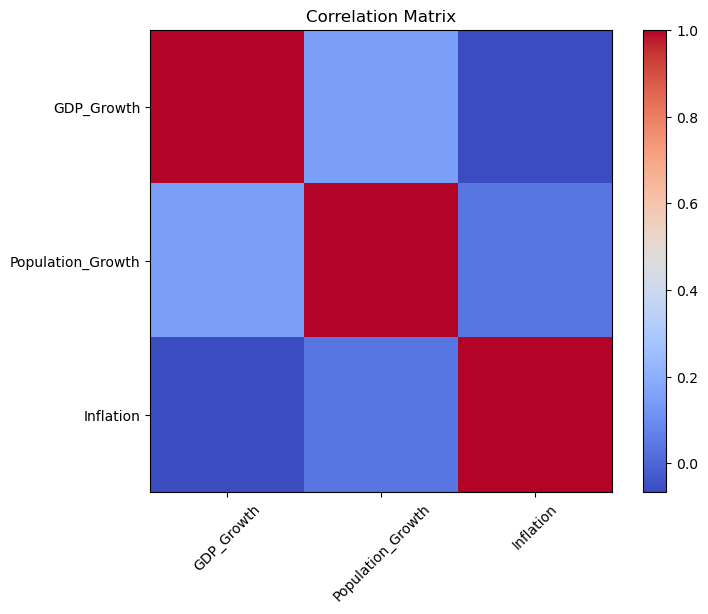

In [290]:
print("\nSummary Statistics:")
print(df.describe())

print("\nFirst 5 rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nSummary Statistics:")
print(df.describe())

# CORRELATION MATRIX
correlation = df[['GDP_Growth', 'Population_Growth', 'Inflation']].corr()

print("\nCorrelation Matrix:")
print(correlation)

plt.figure(figsize=(8,6))
plt.imshow(correlation, cmap='coolwarm', interpolation='nearest')
plt.colorbar()
plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=45)
plt.yticks(range(len(correlation.columns)), correlation.columns)
plt.title("Correlation Matrix")
plt.show()

### IV. EXPLORATORY DATA ANALYSIS (EDA)
#### TREND ANALYSIS

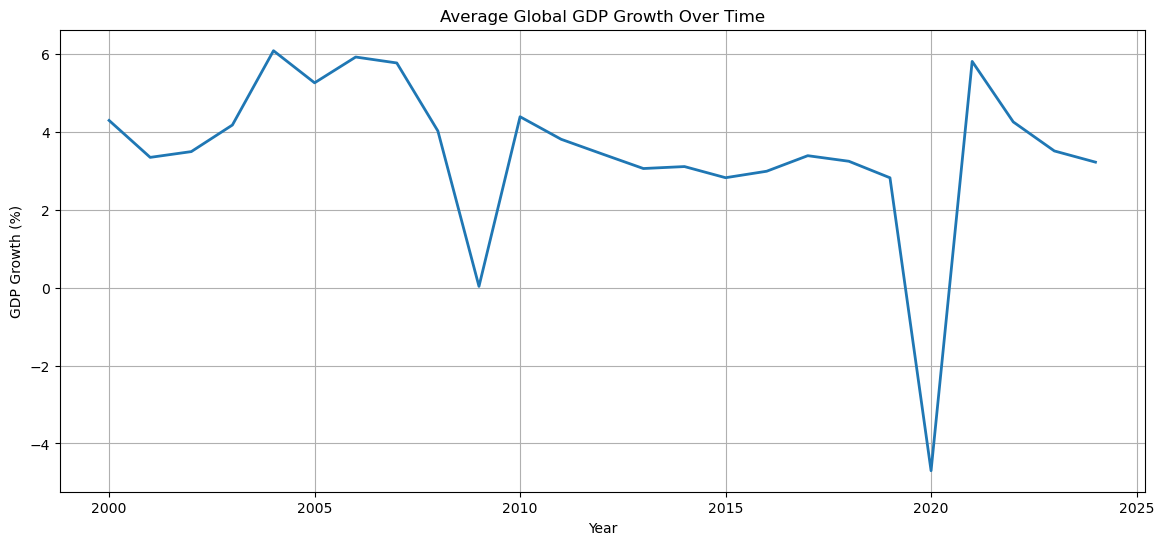

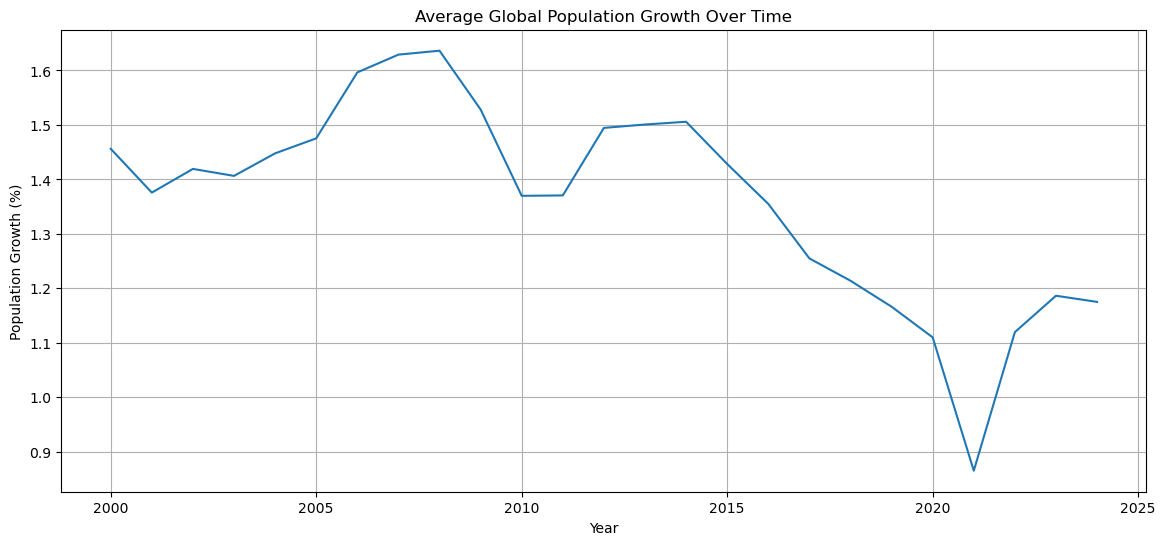

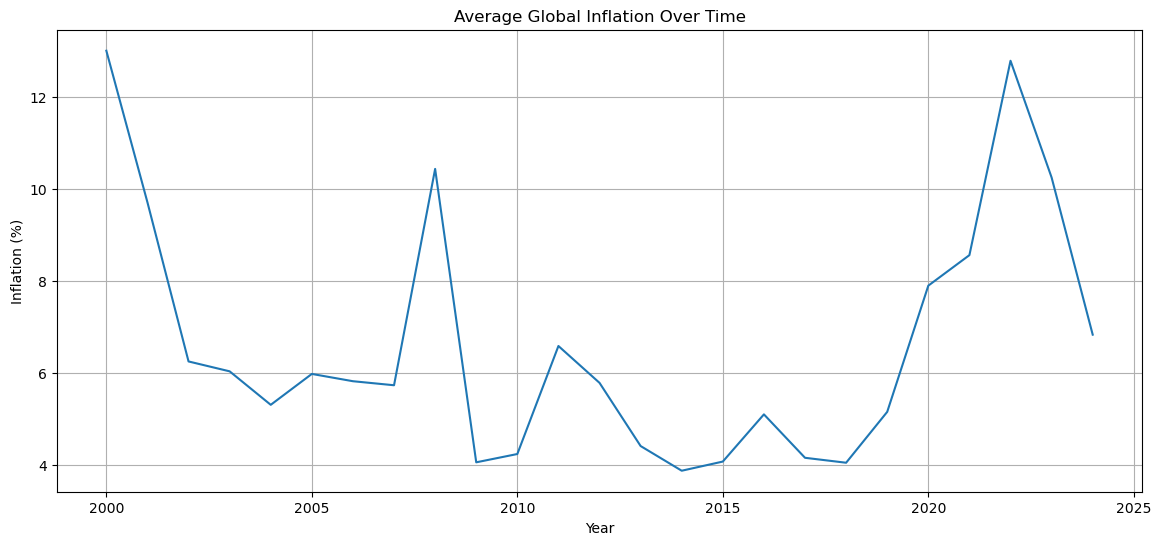


Đánh giá phân tích xu hướng:

1. Tăng trưởng GDP toàn cầu biến động mạnh theo thời gian, phản ánh rõ các chu kỳ kinh tế,
   giai đoạn suy thoái và phục hồi kinh tế toàn cầu.

2. Tốc độ tăng dân số có xu hướng ổn định hơn và giảm dần trong dài hạn,
   cho thấy lực lượng lao động tại nhiều quốc gia đang tăng chậm lại.

3. Lạm phát biến động mạnh hơn, đặc biệt trong các giai đoạn khủng hoảng kinh tế,
   thể hiện mức độ bất ổn vĩ mô của nhiều nền kinh tế.

4. Xu hướng lịch sử cho thấy GDP Growth chịu ảnh hưởng đồng thời từ:
   - Yếu tố nhân khẩu học
   - Chính sách tiền tệ
   - Biến động kinh tế toàn cầu



In [291]:

# Global GDP
avg_gdp = df.groupby('Year')['GDP_Growth'].mean()

plt.figure(figsize=(14,6))
plt.plot(avg_gdp.index, avg_gdp.values, linewidth=2)
plt.title("Average Global GDP Growth Over Time")
plt.xlabel("Year")
plt.ylabel("GDP Growth (%)")
plt.grid(True)
plt.show()

# Population 
avg_population = df.groupby('Year')['Population_Growth'].mean()

plt.figure(figsize=(14,6))
plt.plot(avg_population.index, avg_population.values)
plt.title("Average Global Population Growth Over Time")
plt.xlabel("Year")
plt.ylabel("Population Growth (%)")
plt.grid(True)
plt.show()

# Inflation 
avg_inflation = df.groupby('Year')['Inflation'].mean()

plt.figure(figsize=(14,6))
plt.plot(avg_inflation.index, avg_inflation.values)
plt.title("Average Global Inflation Over Time")
plt.xlabel("Year")
plt.ylabel("Inflation (%)")
plt.grid(True)
plt.show()

print("\nĐánh giá phân tích xu hướng:")
print("""
1. Tăng trưởng GDP toàn cầu biến động mạnh theo thời gian, phản ánh rõ các chu kỳ kinh tế,
   giai đoạn suy thoái và phục hồi kinh tế toàn cầu.

2. Tốc độ tăng dân số có xu hướng ổn định hơn và giảm dần trong dài hạn,
   cho thấy lực lượng lao động tại nhiều quốc gia đang tăng chậm lại.

3. Lạm phát biến động mạnh hơn, đặc biệt trong các giai đoạn khủng hoảng kinh tế,
   thể hiện mức độ bất ổn vĩ mô của nhiều nền kinh tế.

4. Xu hướng lịch sử cho thấy GDP Growth chịu ảnh hưởng đồng thời từ:
   - Yếu tố nhân khẩu học
   - Chính sách tiền tệ
   - Biến động kinh tế toàn cầu
""")


#### DISTRIBUTION ANALYSIS

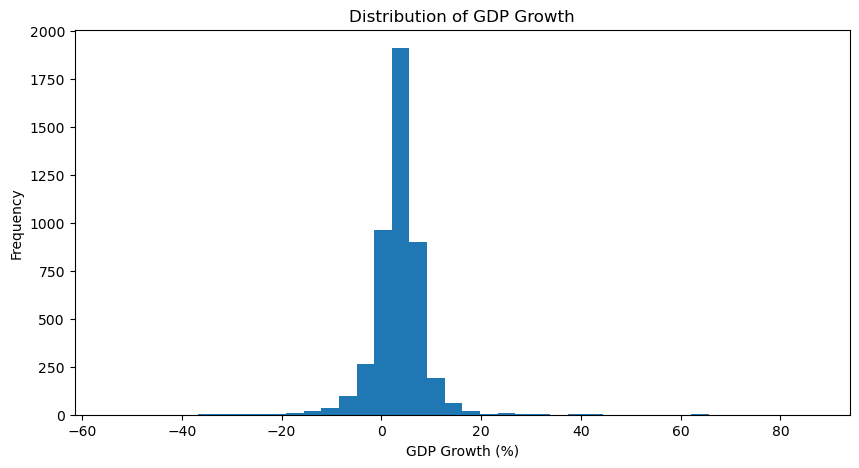

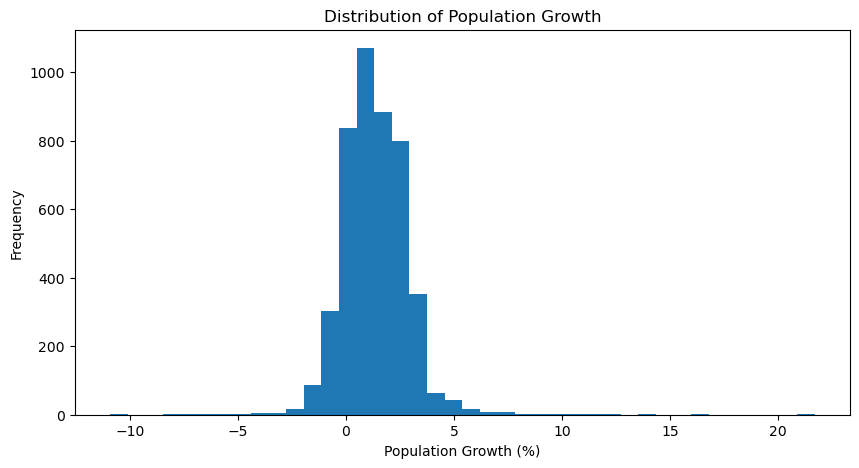

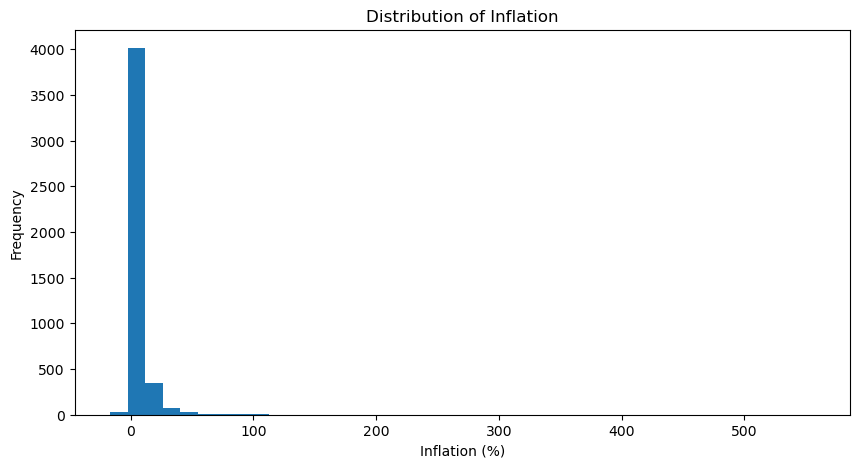


Đánh giá phân tích phân phối:

1. GDP Growth có phân phối khá rộng, cho thấy sự khác biệt lớn giữa các quốc gia
   về tốc độ phát triển kinh tế.

2. Population Growth có phân phối tập trung hơn,
   phản ánh yếu tố dân số thường ổn định hơn so với tăng trưởng kinh tế.

3. Inflation xuất hiện nhiều giá trị ngoại lệ,
   cho thấy một số quốc gia trải qua lạm phát cực cao hoặc mất ổn định kinh tế.

4. Độ phân tán lớn của GDP và Inflation cho thấy mối quan hệ kinh tế không hoàn toàn tuyến tính,
   do đó các mô hình Machine Learning nâng cao sẽ phù hợp hơn.



In [292]:
# GDP Growth Distribution
plt.figure(figsize=(10,5))
plt.hist(df['GDP_Growth'], bins=40)
plt.title("Distribution of GDP Growth")
plt.xlabel("GDP Growth (%)")
plt.ylabel("Frequency")
plt.show()


# Population Growth Distribution
plt.figure(figsize=(10,5))
plt.hist(df['Population_Growth'], bins=40)
plt.title("Distribution of Population Growth")
plt.xlabel("Population Growth (%)")
plt.ylabel("Frequency")
plt.show()


# Inflation Distribution
plt.figure(figsize=(10,5))
plt.hist(df['Inflation'], bins=40)
plt.title("Distribution of Inflation")
plt.xlabel("Inflation (%)")
plt.ylabel("Frequency")
plt.show()

print("\nĐánh giá phân tích phân phối:")
print("""
1. GDP Growth có phân phối khá rộng, cho thấy sự khác biệt lớn giữa các quốc gia
   về tốc độ phát triển kinh tế.

2. Population Growth có phân phối tập trung hơn,
   phản ánh yếu tố dân số thường ổn định hơn so với tăng trưởng kinh tế.

3. Inflation xuất hiện nhiều giá trị ngoại lệ,
   cho thấy một số quốc gia trải qua lạm phát cực cao hoặc mất ổn định kinh tế.

4. Độ phân tán lớn của GDP và Inflation cho thấy mối quan hệ kinh tế không hoàn toàn tuyến tính,
   do đó các mô hình Machine Learning nâng cao sẽ phù hợp hơn.
""")


#### SCATTER PLOT ANALYSIS

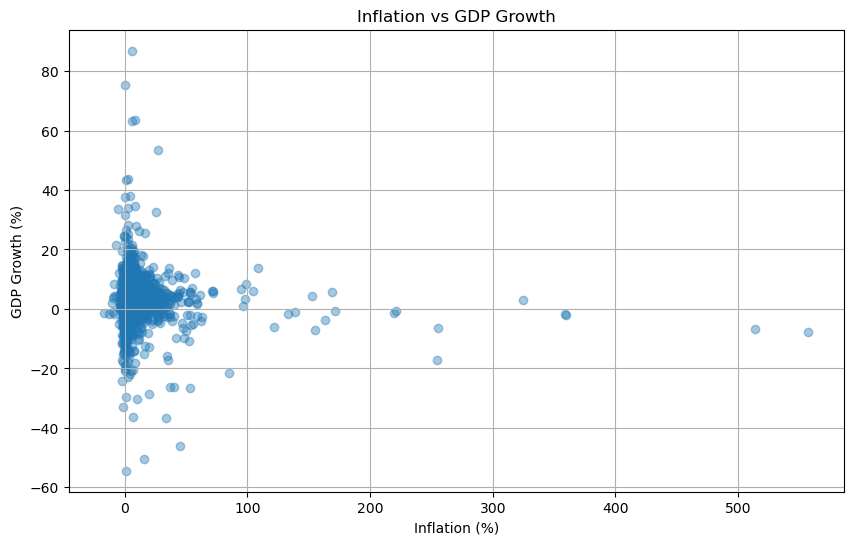

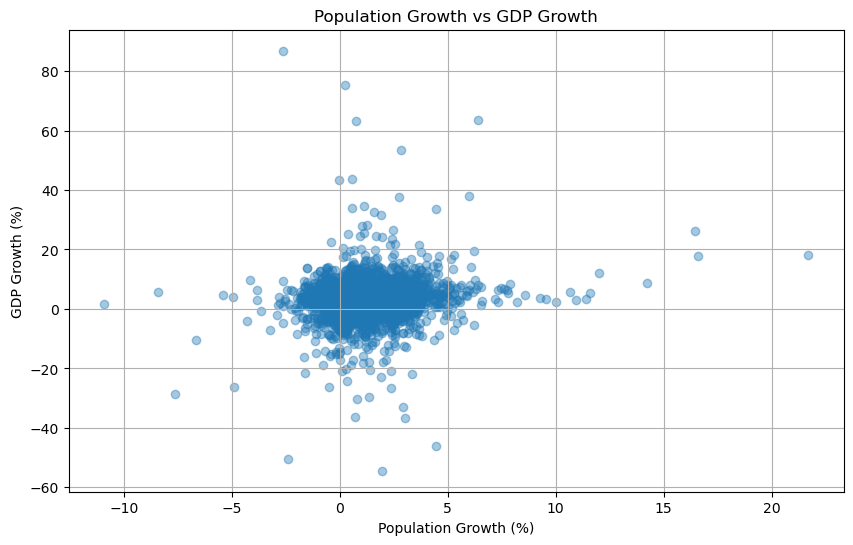


Đánh giá biểu đồ phân tán:

1. Mối quan hệ giữa lạm phát và GDP Growth tương đối yếu nhưng có xu hướng phi tuyến.

2. Các quốc gia có lạm phát quá cao thường đi kèm tăng trưởng GDP thấp hoặc âm,
   phản ánh rủi ro mất ổn định kinh tế.

3. Population Growth có mối quan hệ tích cực vừa phải với GDP Growth,
   đặc biệt rõ hơn ở các nền kinh tế đang phát triển.

4. Kết quả cho thấy GDP Growth chịu ảnh hưởng từ nhiều yếu tố đồng thời,
   vì vậy mô hình phi tuyến như Random Forest có thể cho hiệu quả tốt hơn.



In [293]:
# Scatter Plot: Inflation vs GDP Growth
plt.figure(figsize=(10,6))
plt.scatter(
    df['Inflation'],
    df['GDP_Growth'],
    alpha=0.4
)
plt.title("Inflation vs GDP Growth")
plt.xlabel("Inflation (%)")
plt.ylabel("GDP Growth (%)")
plt.grid(True)
plt.show()

# Scatter Plot: Population vs GDP Growth
plt.figure(figsize=(10,6))
plt.scatter(
    df['Population_Growth'],
    df['GDP_Growth'],
    alpha=0.4
)
plt.title("Population Growth vs GDP Growth")
plt.xlabel("Population Growth (%)")
plt.ylabel("GDP Growth (%)")
plt.grid(True)
plt.show()

print("\nĐánh giá biểu đồ phân tán:")
print("""
1. Mối quan hệ giữa lạm phát và GDP Growth tương đối yếu nhưng có xu hướng phi tuyến.

2. Các quốc gia có lạm phát quá cao thường đi kèm tăng trưởng GDP thấp hoặc âm,
   phản ánh rủi ro mất ổn định kinh tế.

3. Population Growth có mối quan hệ tích cực vừa phải với GDP Growth,
   đặc biệt rõ hơn ở các nền kinh tế đang phát triển.

4. Kết quả cho thấy GDP Growth chịu ảnh hưởng từ nhiều yếu tố đồng thời,
   vì vậy mô hình phi tuyến như Random Forest có thể cho hiệu quả tốt hơn.
""")


#### COUNTRY RANKING + CRISIS ANALYSIS RANKING

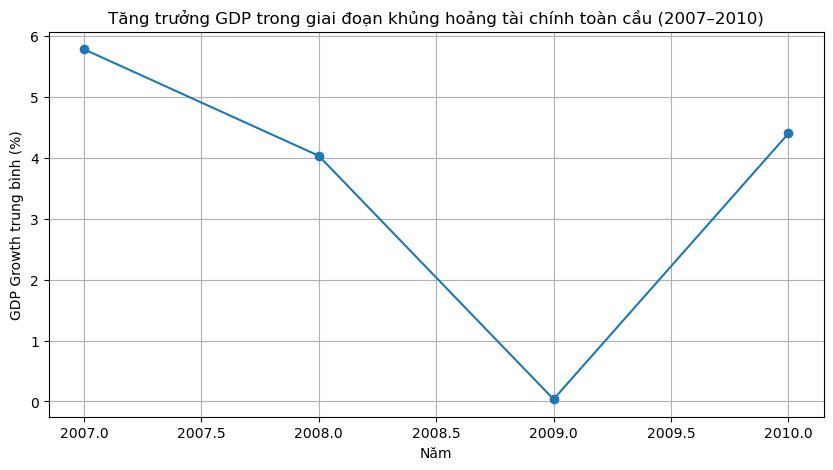

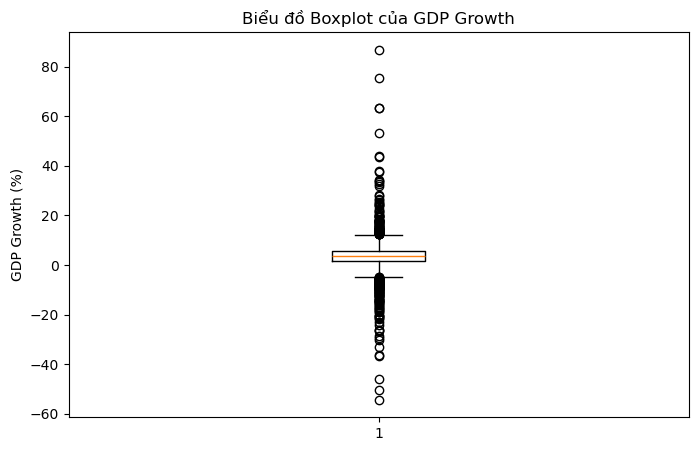

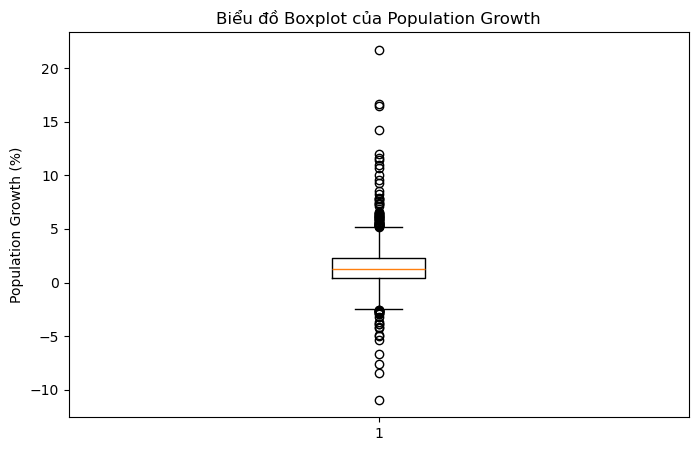

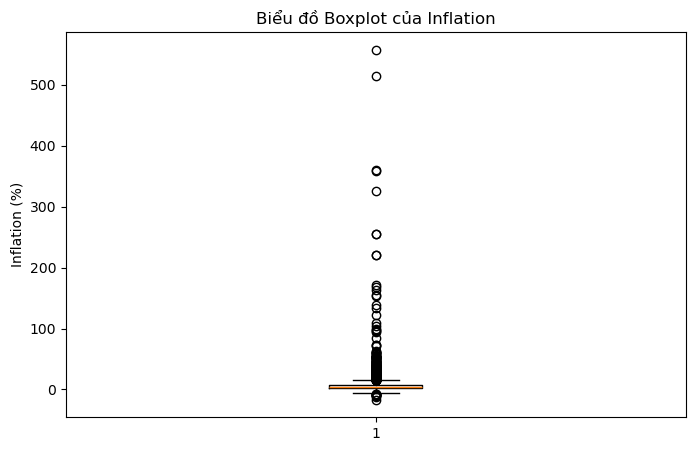


Bảng tổng hợp EDA:
                         Chỉ số  Giá trị
0              Tổng số quốc gia   194.00
1                   Tổng số năm    25.00
2         GDP Growth trung bình     3.50
3  Population Growth trung bình     1.36
4          Inflation trung bình     6.58

Phân tích EDA đã hoàn tất thành công!
Các kết quả đã tạo:
- Ma trận tương quan
- Biểu đồ xu hướng
- Biểu đồ phân phối
- Scatter plots
- Xếp hạng quốc gia Top/Bottom
- Phân tích khủng hoảng kinh tế 2008
- Boxplots
- File eda_summary.csv


In [294]:
crisis_data = df[df['Year'].between(2007, 2010)]

crisis_avg = crisis_data.groupby('Year')['GDP_Growth'].mean()

plt.figure(figsize=(10,5))
plt.plot(crisis_avg.index, crisis_avg.values, marker='o')
plt.title("Tăng trưởng GDP trong giai đoạn khủng hoảng tài chính toàn cầu (2007–2010)")
plt.xlabel("Năm")
plt.ylabel("GDP Growth trung bình (%)")
plt.grid(True)
plt.show()


# BOXPLOT PHÂN TÍCH ĐỘ PHÂN TÁN DỮ LIỆU

# GDP Growth
plt.figure(figsize=(8,5))
plt.boxplot(df['GDP_Growth'].dropna())
plt.title("Biểu đồ Boxplot của GDP Growth")
plt.ylabel("GDP Growth (%)")
plt.show()

# Population Growth
plt.figure(figsize=(8,5))
plt.boxplot(df['Population_Growth'].dropna())
plt.title("Biểu đồ Boxplot của Population Growth")
plt.ylabel("Population Growth (%)")
plt.show()

# Inflation
plt.figure(figsize=(8,5))
plt.boxplot(df['Inflation'].dropna())
plt.title("Biểu đồ Boxplot của Inflation")
plt.ylabel("Inflation (%)")
plt.show()


# BẢNG TỔNG HỢP CÁC CHỈ SỐ KINH TẾ

eda_summary = pd.DataFrame({
    'Chỉ số': [
        'Tổng số quốc gia',
        'Tổng số năm',
        'GDP Growth trung bình',
        'Population Growth trung bình',
        'Inflation trung bình'
    ],
    'Giá trị': [
        df['Country Code'].nunique(),
        df['Year'].nunique(),
        round(df['GDP_Growth'].mean(), 2),
        round(df['Population_Growth'].mean(), 2),
        round(df['Inflation'].mean(), 2)
    ]
})

print("\nBảng tổng hợp EDA:")
print(eda_summary)


# Lưu bảng tổng hợp
eda_summary.to_csv("eda_summary.csv", index=False)


# KẾT LUẬN EDA

print("\nPhân tích EDA đã hoàn tất thành công!")
print("Các kết quả đã tạo:")
print("- Ma trận tương quan")
print("- Biểu đồ xu hướng")
print("- Biểu đồ phân phối")
print("- Scatter plots")
print("- Xếp hạng quốc gia Top/Bottom")
print("- Phân tích khủng hoảng kinh tế 2008")
print("- Boxplots")
print("- File eda_summary.csv")

### V. FEATURE ENGINEERING

In [295]:
# Sắp xếp dữ liệu theo quốc gia và năm
df = df.sort_values(['Country Code', 'Year'])


# GDP của năm trước
df['GDP_lag1'] = df.groupby('Country Code')['GDP_Growth'].shift(1)

# GDP của 2 năm trước
df['GDP_lag2'] = df.groupby('Country Code')['GDP_Growth'].shift(2)


# GDP trung bình trượt 3 năm
df['GDP_rolling_avg'] = (
    df.groupby('Country Code')['GDP_Growth']
    .rolling(window=3)
    .mean()
    .reset_index(0, drop=True)
)


# Xóa các giá trị thiếu sau khi tạo biến mới
df.dropna(inplace=True)


print("\nQuá trình tạo đặc trưng (Feature Engineering) đã hoàn tất!")
print(df.head())


# Lưu bộ dữ liệu hoàn chỉnh
df.to_csv("final_merged_dataset.csv", index=False)

print("\nĐã lưu file: final_merged_dataset.csv")


Quá trình tạo đặc trưng (Feature Engineering) đã hoàn tất!
     Country Name Country Code  Year GDP_Growth Population_Growth Inflation  \
334         Aruba          ABW  2002  -0.944953          0.692052  3.315247   
505         Aruba          ABW  2003   1.110505          1.138229  3.656365   
678         Aruba          ABW  2004   7.293728          2.135358  2.529129   
852         Aruba          ABW  2005  -0.383138          2.590757  3.397787   
1029        Aruba          ABW  2006   1.127411          1.796638  3.608024   

      GDP_lag1  GDP_lag2  GDP_rolling_avg  
334   4.182002  7.622921         3.619990  
505  -0.944953  4.182002         1.449184  
678   1.110505 -0.944953         2.486426  
852   7.293728  1.110505         2.673698  
1029 -0.383138  7.293728         2.679334  

Đã lưu file: final_merged_dataset.csv


### VI. MODEL SELECTION

In [296]:
# Các biến đầu vào sử dụng cho mô hình
features = [
    'Population_Growth',
    'Inflation',
    'GDP_lag1',
    'GDP_lag2',
    'GDP_rolling_avg'
]

# X: Biến độc lập
X = df[features]

# y: Biến mục tiêu (GDP Growth)
y = df['GDP_Growth']


# Chia dữ liệu thành tập huấn luyện và kiểm tra
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# Mô hình 1: Hồi quy tuyến tính
linear_model = LinearRegression()

# Huấn luyện mô hình
linear_model.fit(X_train, y_train)

# Dự đoán
linear_pred = linear_model.predict(X_test)


# Mô hình 2: Random Forest
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Huấn luyện mô hình
rf_model.fit(X_train, y_train)

# Dự đoán
rf_pred = rf_model.predict(X_test)

### VII. EVALUATION


Hiệu suất mô hình Linear Regression:
MAE: 0.0
RMSE: 0.0
R² Score: 1.0

Hiệu suất mô hình Random Forest:
MAE: 0.8448
RMSE: 2.5436
R² Score: 0.813

Mức độ quan trọng của các biến:
             Feature  Importance
4    GDP_rolling_avg    0.530584
2           GDP_lag1    0.244531
3           GDP_lag2    0.181061
0  Population_Growth    0.026964
1          Inflation    0.016859


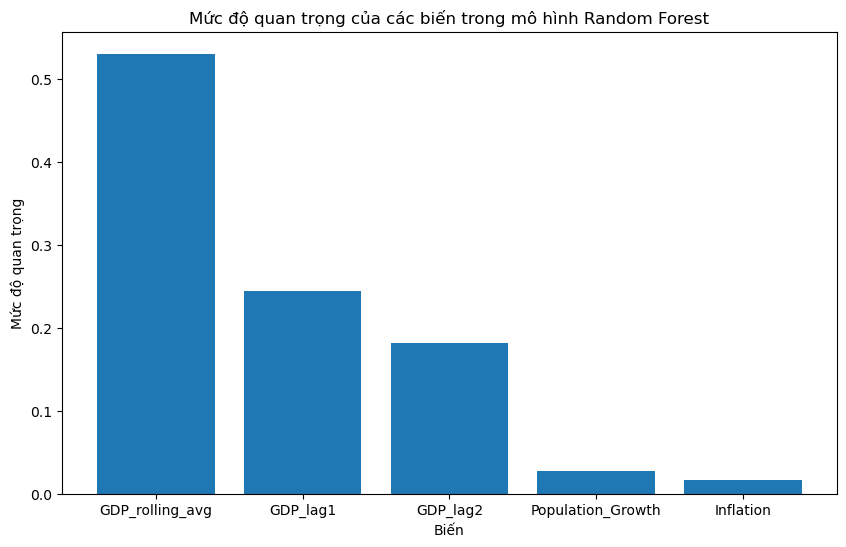

In [297]:
def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"\nHiệu suất mô hình {name}:")
    print("MAE:", round(mae, 4))
    print("RMSE:", round(rmse, 4))
    print("R² Score:", round(r2, 4))


# Đánh giá cả hai mô hình
evaluate_model("Linear Regression", y_test, linear_pred)
evaluate_model("Random Forest", y_test, rf_pred)


# Tầm quan trọng của các biến từ Random Forest
importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print("\nMức độ quan trọng của các biến:")
print(importance)


plt.figure(figsize=(10,6))
plt.bar(
    importance['Feature'],
    importance['Importance']
)

plt.title("Mức độ quan trọng của các biến trong mô hình Random Forest")
plt.xlabel("Biến")
plt.ylabel("Mức độ quan trọng")
plt.show()

### VIII. ECONOMIC INSIGHTS

In [298]:
print("\nPhân tích chuyên sâu về kinh tế:")

top_features = importance.head(3)

for index, row in top_features.iterrows():
    print(
        f"- {row['Feature']} là một yếu tố quan trọng ảnh hưởng đến tăng trưởng GDP "
        f"(mức độ quan trọng: {round(row['Importance'], 4)})"
    )

print("""
Những phát hiện chính:
1. Xu hướng GDP trong quá khứ có khả năng dự báo rất mạnh đối với tăng trưởng GDP tương lai.
2. Tăng trưởng dân số góp phần mở rộng lực lượng lao động và hỗ trợ phát triển kinh tế.
3. Lạm phát ảnh hưởng đáng kể đến sự ổn định kinh tế vĩ mô.
4. Mô hình Random Forest thường phản ánh tốt hơn các mối quan hệ kinh tế phi tuyến.
5. Các quốc gia duy trì các chỉ số kinh tế vĩ mô ổn định thường có tăng trưởng GDP dễ dự đoán hơn.
""")


Phân tích chuyên sâu về kinh tế:
- GDP_rolling_avg là một yếu tố quan trọng ảnh hưởng đến tăng trưởng GDP (mức độ quan trọng: 0.5306)
- GDP_lag1 là một yếu tố quan trọng ảnh hưởng đến tăng trưởng GDP (mức độ quan trọng: 0.2445)
- GDP_lag2 là một yếu tố quan trọng ảnh hưởng đến tăng trưởng GDP (mức độ quan trọng: 0.1811)

Những phát hiện chính:
1. Xu hướng GDP trong quá khứ có khả năng dự báo rất mạnh đối với tăng trưởng GDP tương lai.
2. Tăng trưởng dân số góp phần mở rộng lực lượng lao động và hỗ trợ phát triển kinh tế.
3. Lạm phát ảnh hưởng đáng kể đến sự ổn định kinh tế vĩ mô.
4. Mô hình Random Forest thường phản ánh tốt hơn các mối quan hệ kinh tế phi tuyến.
5. Các quốc gia duy trì các chỉ số kinh tế vĩ mô ổn định thường có tăng trưởng GDP dễ dự đoán hơn.



### IX. FINAL CONCLUSION

In [299]:
print("\nDự án đã hoàn thành thành công!")
print("Các kết quả đã tạo:")
print("- final_merged_dataset.csv")
print("- Các biểu đồ trực quan hóa EDA")
print("- Các chỉ số đánh giá hiệu suất mô hình")
print("- Các phân tích và insight kinh tế")


Dự án đã hoàn thành thành công!
Các kết quả đã tạo:
- final_merged_dataset.csv
- Các biểu đồ trực quan hóa EDA
- Các chỉ số đánh giá hiệu suất mô hình
- Các phân tích và insight kinh tế
